In [ ]:
# DATA RELATIONSHIPS
# Parent_Table, Child_Table, Join Key
# providers, appointments, provider_id
# departments, providers, department_id


In [8]:
import pandas as pd
import numpy as np
providers = pd.read_csv("providers.csv")

In [11]:
import pandas as pd
import numpy as np

# Load the raw dataset
df = pd.read_csv('providers.csv')

# Structural Integrity & Data Types ---
print("--- 1. Structural Overview & Data Types ---")
print(df.info())
print("\nShape of dataset (Rows, Columns):", df.shape)

# Missing / Null Values ---
print("\n--- 2. Missing (Null) Value Count ---")
missing_counts = df.isna().sum()
print(missing_counts[missing_counts > 0] if missing_counts.sum() > 0 else "No strict NaN/Null values found.")

# Check for hidden string placeholders like 'NULL', 'None', ' ', or '?'
print("\nChecking for hidden placeholder strings:")
for col in df.select_dtypes(include=['object']).columns:
    placeholders = df[df[col].astype(str).str.strip().isin(['', '?', 'NULL', 'None', 'nan'])]
    print(f"  Column '{col}' has {len(placeholders)} hidden blank/placeholder rows.")


# Duplicate Records ---
print("\n--- 3. Duplicate Checks ---")
exact_duplicates = df.duplicated().sum()
id_duplicates = df['provider_id'].duplicated().sum()
print(f"  Exact row duplicates: {exact_duplicates}")
print(f"  Duplicate Provider IDs (Primary Key violations): {id_duplicates}")


# Boundary & Logical Constraints (Outliers) ---
print("\n--- 4. Logical Value Boundaries & Outliers ---")

# Check negative values or zeroes where they shouldn't exist
print(f"  Providers with 0 or negative experience: {len(df[df['years_experience'] <= 0])}")
print(f"  Providers with 0 or negative panel size: {len(df[df['provider_panel_size'] <= 0])}")
print(f"  Providers with 0 or negative visit duration: {len(df[df['avg_visit_duration_min'] <= 0])}")
print(f"  Providers with negative overbooking index: {len(df[df['overbooking_index'] < 0])}")

# Check for statistical outliers using descriptive statistics
print("\nDistribution Summary for Numeric Columns:")
print(df.describe())


# Categorical Consistency ---
print("\n--- 5. Categorical Consistency & Whitespace Checks ---")

# Check if there are trailing/leading spaces causing duplicate categories (e.g., ' Oncology' vs 'Oncology')
for col in ['specialty', 'department_id']:
    raw_unique = df[col].nunique()
    stripped_unique = df[col].astype(str).str.strip().str.title().nunique()
    if raw_unique != stripped_unique:
        print(f"  [PROBLEM ALERT] Column '{col}' has whitespace or casing inconsistencies!")
        print(f"    Raw unique count: {raw_unique} | Cleaned unique count: {stripped_unique}")
    else:
        print(f"  Column '{col}' looks consistent (Unique count: {raw_unique}).")

--- 1. Structural Overview & Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   provider_id             2000 non-null   object 
 1   department_id           2000 non-null   object 
 2   specialty               2000 non-null   object 
 3   years_experience        2000 non-null   int64  
 4   provider_panel_size     2000 non-null   int64  
 5   avg_visit_duration_min  2000 non-null   float64
 6   overbooking_index       2000 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 109.5+ KB
None

Shape of dataset (Rows, Columns): (2000, 7)

--- 2. Missing (Null) Value Count ---
No strict NaN/Null values found.

Checking for hidden placeholder strings:
  Column 'provider_id' has 0 hidden blank/placeholder rows.
  Column 'department_id' has 0 hidden blank/placeholder rows.
  Column 'specialty' ha

In [12]:
def clean_providers_data():
    # String Sanitization & Case Standardization
    # Strip hidden whitespaces and standardize categorical columns
    providers['provider_id'] = providers['provider_id'].astype(str).str.strip().str.upper()
    providers['department_id'] = providers['department_id'].astype(str).str.strip().str.upper()
    providers['specialty'] = providers['specialty'].astype(str).str.strip().str.title()
    
    # Type Enforcement & Handling Outliers/Anomalies
    providers['years_experience'] = pd.to_numeric(providers['years_experience'], errors='coerce').astype('Int64')
    providers['provider_panel_size'] = pd.to_numeric(providers['provider_panel_size'], errors='coerce').astype('Int64')
    providers['avg_visit_duration_min'] = pd.to_numeric(providers['avg_visit_duration_min'], errors='coerce')
    providers['overbooking_index'] = pd.to_numeric(providers['overbooking_index'], errors='coerce')
    
    # Handle Duplicates
    duplicate_ids = providers.duplicated(subset=['provider_id']).sum()
    if duplicate_ids > 0:
        print(f"[Warning] Found {duplicate_ids} duplicate provider IDs. Dropping duplicates, keeping first.")
        providers.drop_duplicates(subset=['provider_id'], keep='first', inplace=True)
    
    # Department E Specific Engineering: Flag Administrative Bottlenecks
    # Flag fields where an overbooking index > 1.5 might signify massive administrative/scheduling strain
    providers['high_admin_strain_flag'] = np.where(providers['overbooking_index'] > 1.5, 1, 0)
    
    # Export Cleaned Dataset
    output_filename = "cleaned_providers.csv"
    providers.to_csv(output_filename, index=False)
    print(f"--- Data Cleaning Complete. Saved as '{output_filename}' ---")
    
    # Show Summary Statistics
    print("\nCleaned Dataset Overview:")
    print(providers.info())
    return providers

In [13]:
# Execute the cleaning function
cleaned_providers = clean_providers_data()

--- Data Cleaning Complete. Saved as 'cleaned_providers.csv' ---

Cleaned Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   provider_id             2000 non-null   object 
 1   department_id           2000 non-null   object 
 2   specialty               2000 non-null   object 
 3   years_experience        2000 non-null   Int64  
 4   provider_panel_size     2000 non-null   Int64  
 5   avg_visit_duration_min  2000 non-null   float64
 6   overbooking_index       2000 non-null   float64
 7   high_admin_strain_flag  2000 non-null   int64  
dtypes: Int64(2), float64(2), int64(1), object(3)
memory usage: 129.0+ KB
None


C:\Users\razar\AppData\Local\Temp\ipykernel_28092\4123326670.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_specialty_ob, x='overbooking_index', y='specialty', ax=ax, palette='viridis')
C:\Users\razar\AppData\Local\Temp\ipykernel_28092\4123326670.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_specialty_ps, x='provider_panel_size', y='specialty', ax=ax, palette='magma')
C:\Users\razar\AppData\Local\Temp\ipykernel_28092\4123326670.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_dept_ob, x='overbooking_i

Visualizations generated successfully.


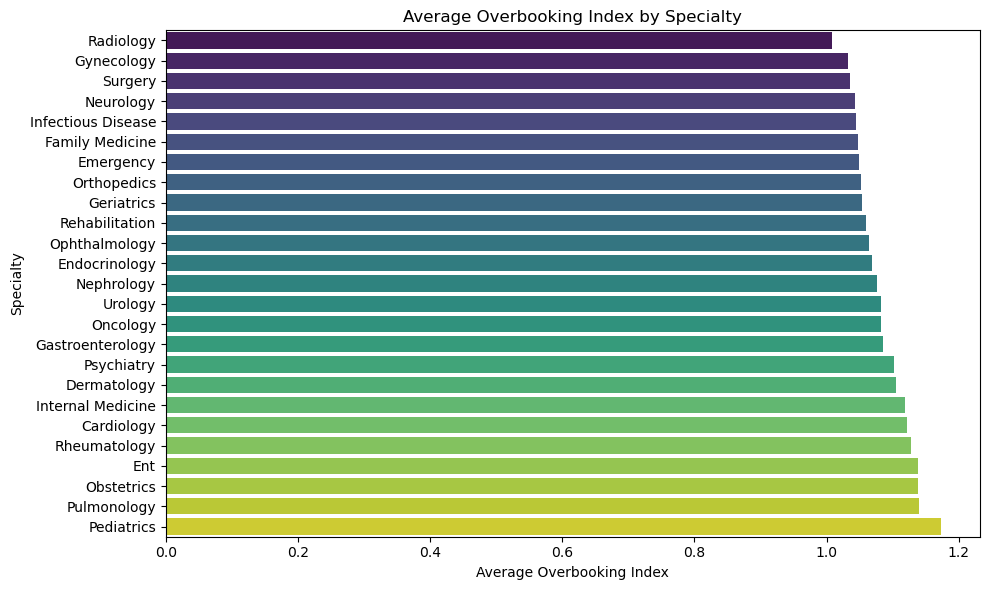

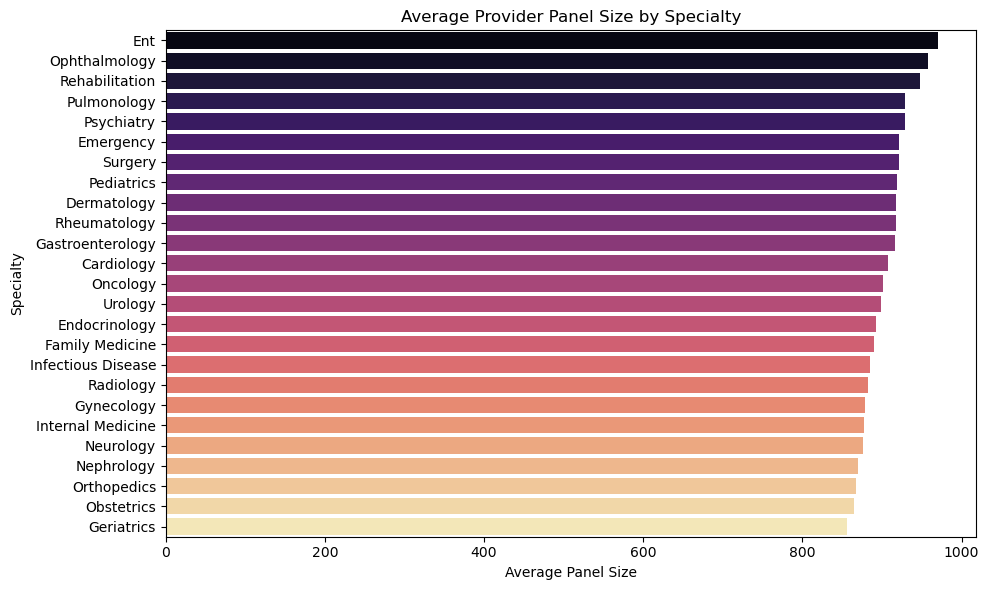

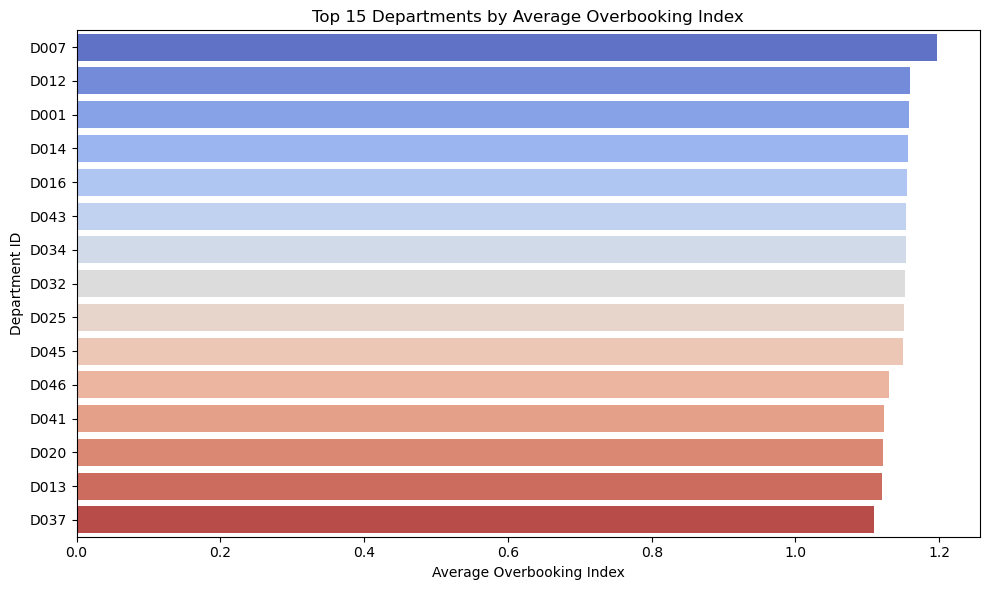

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = cleaned_providers

# Group by specialty for different metrics
metrics = ['overbooking_index', 'provider_panel_size', 'avg_visit_duration_min', 'years_experience']

# Overbooking Index by Specialty
df_specialty_ob = df.groupby('specialty')['overbooking_index'].mean().sort_values().reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df_specialty_ob, x='overbooking_index', y='specialty', ax=ax, palette='viridis')
ax.set_title('Average Overbooking Index by Specialty')
ax.set_xlabel('Average Overbooking Index')
ax.set_ylabel('Specialty')
plt.tight_layout()
plt.savefig('specialty_overbooking.png')

# Provider Panel Size by Specialty
df_specialty_ps = df.groupby('specialty')['provider_panel_size'].mean().sort_values(ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df_specialty_ps, x='provider_panel_size', y='specialty', ax=ax, palette='magma')
ax.set_title('Average Provider Panel Size by Specialty')
ax.set_xlabel('Average Panel Size')
ax.set_ylabel('Specialty')
plt.tight_layout()
plt.savefig('specialty_panel_size.png')

# Top 10 Departments by Overbooking Index
df_dept_ob = df.groupby('department_id')['overbooking_index'].mean().sort_values(ascending=False).head(15).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df_dept_ob, x='overbooking_index', y='department_id', ax=ax, palette='coolwarm')
ax.set_title('Top 15 Departments by Average Overbooking Index')
ax.set_xlabel('Average Overbooking Index')
ax.set_ylabel('Department ID')
plt.tight_layout()
plt.savefig('dept_overbooking_top15.png')

print("Visualizations generated successfully.")